In [36]:
# Importing libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import QuantileTransformer

In [37]:
df = pd.read_csv("housing.csv")

In [38]:
# median_house_value - target variable, from project 1 we know that it has big spike on value - 500001
# because all the houses above that value are just marked as 500001
df['median_house_value'].value_counts().sort_index()

median_house_value
14999.0       4
17500.0       1
22500.0       4
25000.0       1
26600.0       1
           ... 
498800.0      1
499000.0      1
499100.0      1
500000.0     27
500001.0    965
Name: count, Length: 3842, dtype: int64

In [39]:
# I will delete those rows above 500000, because quantie transformer will try to fit those values too
df = df[df['median_house_value'] < 500001]

In [40]:
df['median_house_value'].value_counts().sort_index()

median_house_value
14999.0      4
17500.0      1
22500.0      4
25000.0      1
26600.0      1
            ..
498700.0     1
498800.0     1
499000.0     1
499100.0     1
500000.0    27
Name: count, Length: 3841, dtype: int64

In [41]:
housing_qt = df.copy()

In [42]:
housing_qt.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,19675.000000,19675.000000,19675.000000,19675.000000,19475.000000,19675.000000,19675.000000,19675.000000,19675.000000
mean,-119.563192,35.651780,28.386277,2619.763659,539.645751,1440.812198,501.186023,3.676717,192477.921017
std,2.006108,2.149802,12.509113,2181.348207,422.413200,1143.648725,383.264636,1.570272,97711.509613
min,-124.350000,32.540000,1.000000,2.000000,2.000000,3.000000,2.000000,0.499900,14999.000000
25%,-121.760000,33.930000,18.000000,1438.000000,297.000000,796.000000,282.000000,2.526800,116600.000000
50%,-118.500000,34.270000,28.000000,2111.000000,436.000000,1179.000000,411.000000,3.450000,173800.000000
75%,-117.990000,37.730000,37.000000,3120.000000,648.000000,1746.000000,606.000000,4.582600,248200.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500000.000000


In [43]:
housing_qt.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [44]:
# Drop columns you don’t want to transform (non-numeric or not useful)
columns_to_exclude = ['longitude', 'latitude', 'ocean_proximity']

In [45]:
housing_qt = housing_qt.drop(columns=columns_to_exclude)

In [46]:
housing_qt.describe()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,19675.000000,19675.000000,19475.000000,19675.000000,19675.000000,19675.000000,19675.000000
mean,28.386277,2619.763659,539.645751,1440.812198,501.186023,3.676717,192477.921017
std,12.509113,2181.348207,422.413200,1143.648725,383.264636,1.570272,97711.509613
min,1.000000,2.000000,2.000000,3.000000,2.000000,0.499900,14999.000000
25%,18.000000,1438.000000,297.000000,796.000000,282.000000,2.526800,116600.000000
50%,28.000000,2111.000000,436.000000,1179.000000,411.000000,3.450000,173800.000000
75%,37.000000,3120.000000,648.000000,1746.000000,606.000000,4.582600,248200.000000
max,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500000.000000


In [47]:
# Select all remaining numeric columns automatically
columns_to_transform = housing_qt.select_dtypes(include=['int64', 'float64']).columns

In [48]:
# Initialize the QuantileTransformer
qt = QuantileTransformer(output_distribution='normal', random_state=42)

In [49]:
# Apply the transformation
housing_qt[columns_to_transform] = qt.fit_transform(housing_qt[columns_to_transform])

housing_qt.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,0.951518,-1.356810,-1.716415,-1.724463,-1.669112,2.408833,2.180592
1,-0.447305,1.826219,1.480589,1.179851,1.633555,2.399623,1.440788
2,5.199338,-0.643572,-1.352623,-1.348459,-1.344179,1.897094,1.398767
3,5.199338,-0.860725,-1.070745,-1.204935,-1.086456,1.192983,1.297200
4,5.199338,-0.457443,-0.793602,-1.191307,-0.823172,0.238160,1.304121


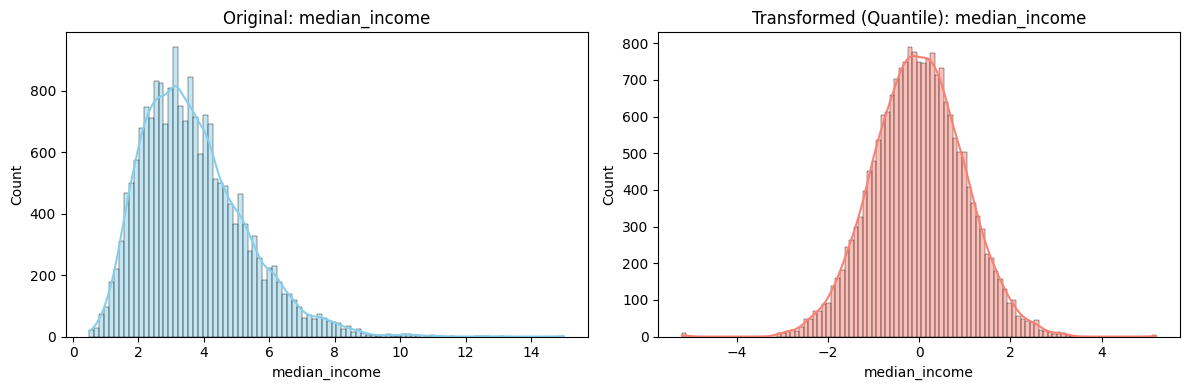

In [50]:
# let's cheeck some variables distributions before and after transformation
col = 'median_income'

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# histogram of original dataset
sns.histplot(df[col], kde=True, ax=axs[0], color='skyblue')
axs[0].set_title(f'Original: {col}')

# histogram of transformed dataset
sns.histplot(housing_qt[col], kde=True, ax=axs[1], color='salmon')
axs[1].set_title(f'Transformed: {col}')

plt.tight_layout()
plt.show()

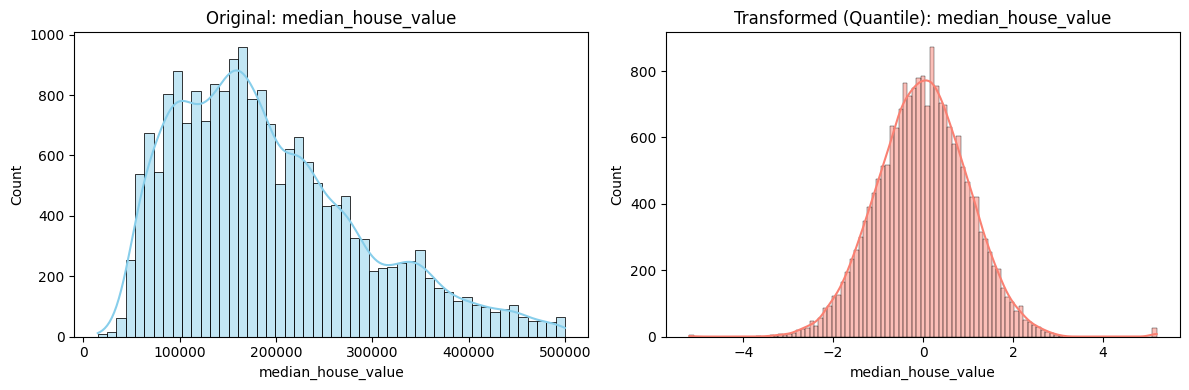

In [51]:
# target variable:
col = 'median_house_value'

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# histogram of original dataset
sns.histplot(df[col], kde=True, ax=axs[0], color='skyblue')
axs[0].set_title(f'Original: {col}')

# histogram of transformed dataset
sns.histplot(housing_qt[col], kde=True, ax=axs[1], color='salmon')
axs[1].set_title(f'Transformed: {col}')

plt.tight_layout()
plt.show()

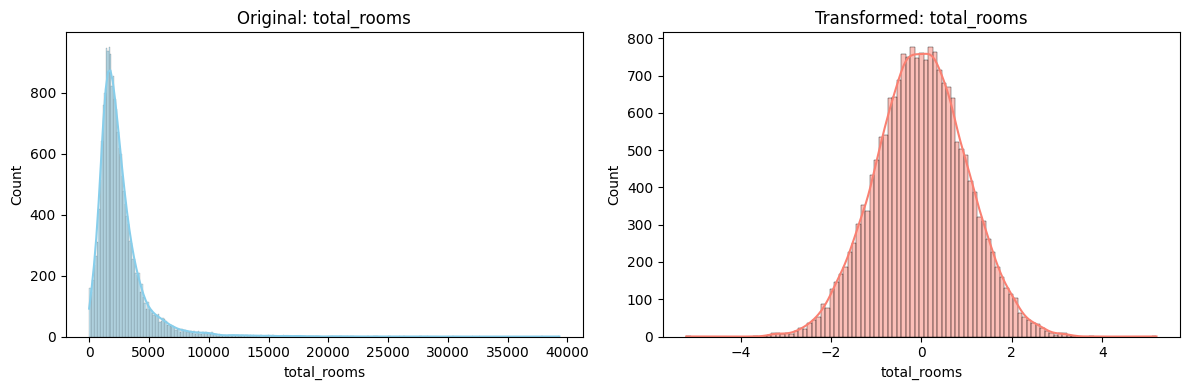

In [52]:
# let's cheeck some variables distributions before and after transformation
col = 'total_rooms'

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# histogram of original dataset
sns.histplot(df[col], kde=True, ax=axs[0], color='skyblue')
axs[0].set_title(f'Original: {col}')

# histogram of transformed dataset
sns.histplot(housing_qt[col], kde=True, ax=axs[1], color='salmon')
axs[1].set_title(f'Transformed: {col}')

plt.tight_layout()
plt.show()

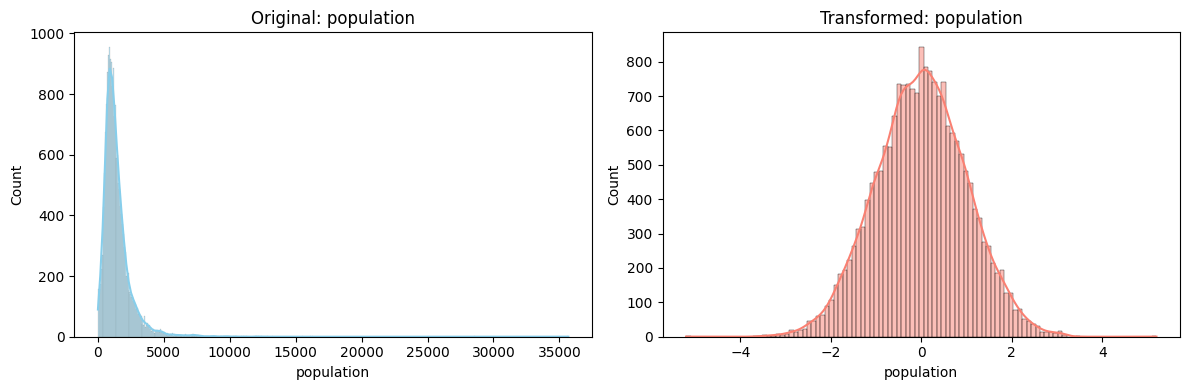

In [53]:
# let's cheeck some variables distributions before and after transformation
col = 'population'

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# histogram of original dataset
sns.histplot(df[col], kde=True, ax=axs[0], color='skyblue')
axs[0].set_title(f'Original: {col}')

# histogram of transformed dataset
sns.histplot(housing_qt[col], kde=True, ax=axs[1], color='salmon')
axs[1].set_title(f'Transformed: {col}')

plt.tight_layout()
plt.show()